In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import files
uploaded = files.upload()

Saving social_media_engagement_5000.csv to social_media_engagement_5000.csv


In [6]:
import pandas as pd

df = pd.read_csv("social_media_engagement_5000.csv")
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-null   object 


In [20]:
print(df.columns)
df['posted_at'] = pd.to_datetime(df['posted_at'])
df['year'] = df['posted_at'].dt.year
df['month'] = df['posted_at'].dt.month
df['day'] = df['posted_at'].dt.day
df

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate', 'year',
       'month', 'day'],
      dtype='object')


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,...,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,year,month,day
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,...,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,2022,12,17
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,...,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,2023,6,2
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,...,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,2023,5,7
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,...,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,2023,2,12
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,...,2023-05-23,383936,False,mobile,negative,#travel,2.777372,2023,5,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,...,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2022,6,25
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,...,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2022,11,18
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,...,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2023,4,6
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,...,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,2022,5,16


In [22]:
df.isnull().sum()

,0
user_id,0
age,150
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,150
comments,150
shares,150


In [28]:
# Clean column names
df.columns = df.columns.str.strip().str.lower()

In [29]:
# Define columns
num_cols = ['likes','comments','shares','impressions','watch_time','followers']

In [30]:
# Keep only existing columns
num_cols = [col for col in num_cols if col in df.columns]

In [31]:
# Convert to numeric
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [32]:
# Fill missing values
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_4526/3206001372.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [34]:
df.drop_duplicates(inplace=True)

In [36]:
# Standardize gender
df['gender'] = df['gender'].str.lower()

In [39]:
# Fix unrealistic values (example)
df = df[df['likes'] >= 0]
df = df[df['comments'] >= 0]
df = df[df['shares'] >= 0]

In [41]:
df['hashtag_count'] = df['hashtags'].apply(lambda x: len(str(x).split()))

In [43]:
df['sentiment'] = df['sentiment'].str.lower()

In [45]:
df.head()
df.tail()
df.shape
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate', 'year',
       'month', 'day', 'hashtag_count'],
      dtype='object')

In [47]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,year,month,day,hashtag_count
count,5000.000000,4850.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.454021,548042.909000,10106.997400,1502.039800,1002.9106,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356,2022.493800,6.499200,15.838600,1.998600
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.0000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,2022.000000,1.000000,1.000000,1.000000
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.0000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,2022.000000,4.000000,8.000000,1.000000
50%,54374.500000,38.000000,548077.500000,10105.500000,1497.000000,1012.0000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2022.000000,7.000000,16.000000,2.000000
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,2023.000000,9.000000,23.000000,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,2023.000000,12.000000,31.000000,3.000000
std,26090.370121,14.912381,260646.957267,5702.293017,856.393312,570.8552,2308.096459,28844.939104,NaN,230927.884535,5.318029,0.500012,3.443599,8.750695,0.812853


In [49]:
df['post_type'].value_counts()
df['country'].nunique()

10

In [51]:
df.corr(numeric_only=True)

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,is_verified,engagement_rate,year,month,day,hashtag_count
user_id,1.000000,-0.006789,0.020051,0.025811,-0.033395,0.013763,-0.016847,0.015326,0.010124,0.004058,-0.004282,-0.018834,0.011608,0.029921,-0.013692
age,-0.006789,1.000000,-0.013353,-0.036767,-0.007369,0.014120,0.005677,0.013513,-0.025416,-0.000112,0.008044,-0.001929,0.005364,-0.026357,0.007336
post_id,0.020051,-0.013353,1.000000,0.014526,-0.010540,0.001846,0.018374,-0.007709,-0.002844,0.025208,0.010139,-0.003782,0.012907,-0.003379,0.007344
likes,0.025811,-0.036767,0.014526,1.000000,-0.018421,0.004712,0.008710,0.007952,-0.022982,-0.016200,0.093520,0.031990,-0.005629,-0.033291,-0.002190
comments,-0.033395,-0.007369,-0.010540,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,-0.012398,0.000051,-0.005589,0.000178,0.025236,-0.015230
shares,0.013763,0.014120,0.001846,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.007025,0.021724,0.006637,0.002860,0.012476,0.013379
watch_time_sec,-0.016847,0.005677,0.018374,0.008710,-0.016351,0.014658,1.000000,-0.004335,0.002761,0.012326,-0.001148,0.018084,-0.017881,-0.019102,-0.023301
impression_count,0.015326,0.013513,-0.007709,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,0.008317,-0.232226,0.003444,0.004226,-0.022784,-0.002714
follower_count,0.010124,-0.025416,-0.002844,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,-0.017808,0.002292,0.002467,-0.005221,0.007261,0.008802
is_verified,0.004058,-0.000112,0.025208,-0.016200,-0.012398,0.007025,0.012326,0.008317,-0.017808,1.000000,0.005528,0.018274,0.020426,0.012145,0.001396


In [54]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

if 'post_type' in df.columns and 'likes' in df.columns:
    print(df.groupby('post_type')['likes'].mean())

if 'country' in df.columns and 'impressions' in df.columns:
    print(df.groupby('country')['impressions'].mean())

post_type
image    10104.865277
reel     10037.802416
text     10100.148193
video    10188.600000
Name: likes, dtype: float64


In [56]:
df['engagement_score'] = df['likes'] + df['comments'] + df['shares']

In [58]:
df.groupby(['post_type','country'])['engagement_score'].mean()

post_type  country  
image      Australia    12352.192913
           Brazil       11891.985816
           Canada       12199.557143
           France       13755.419231
           Germany      12987.921739
           India        12591.358268
           Japan        12172.592233
           UAE          13366.198347
           UK           12356.247967
           USA          12904.416667
reel       Australia    12603.622881
           Brazil       12415.380000
           Canada       12822.251908
           France       12592.364754
           Germany      12028.785714
           India        12084.618750
           Japan        12831.628000
           UAE          12494.379310
           UK           12706.862903
           USA          12736.747934
text       Australia    12914.511628
           Brazil       12699.845528
           Canada       12642.797170
           France       12321.658537
           Germany      12864.772388
           India        12727.897727
           Japan        12562.272358
           UAE          12668.714912
           UK           12237.559829
           USA          12462.399306
video      Australia    13388.365546
           Brazil       12624.017391
           Canada       12787.018382
           France       12892.904959
           Germany      12610.550388
           India        12679.926724
           Japan        12679.603306
           UAE          12552.304878
           UK           12234.360465
           USA          12207.275862
Name: engagement_score, dtype: float64

In [66]:
# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [68]:
# Create feature
df['engagement_score'] = df['likes'] + df['comments'] + df['shares']

In [70]:
# Columns list
cols = ['likes','comments','shares','watch_time','engagement_score','followers']

In [72]:
# Keep only valid columns
cols = [col for col in cols if col in df.columns]

In [74]:
# Convert to numeric
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [76]:
# Stats
print(df[cols].mean())
print(df[cols].median())
print(df[cols].mode())
print(df[cols].std())
print(df[cols].var())
print(df[cols].quantile([0.25,0.5,0.75]))

likes               10106.9974
comments             1502.0398
shares               1002.9106
engagement_score    12611.9478
dtype: float64
likes               10105.50
comments             1497.00
shares               1012.00
engagement_score    12551.75
dtype: float64
     likes  comments  shares  engagement_score
0  10105.5    1497.0  1012.0           21623.0
likes               5702.293017
comments             856.393312
shares               570.855200
engagement_score    5782.058460
dtype: float64
likes               3.251615e+07
comments            7.334095e+05
shares              3.258757e+05
engagement_score    3.343220e+07
dtype: float64
        likes  comments  shares  engagement_score
0.25   5235.0    792.00   511.0           7807.00
0.50  10105.5   1497.00  1012.0          12551.75
0.75  14959.0   2235.25  1483.0          17478.25


In [85]:
print(df.shape)
print(df.head())

(5000, 24)
   user_id   age  gender country  post_id post_type post_category    likes  \
0    25795  43.0  female  Brazil   496713     image       fitness   7011.0   
1    10860  33.0    male  Brazil   157326      reel          food  11750.0   
2    86820  32.0  female      UK   109864      text          food   4862.0   
3    64886  51.0   other  France   848877      text       fitness   5350.0   
4    16265  34.0   other      UK   449706     image       fitness  12682.0   

   comments  shares  ...  is_verified  device_type sentiment  \
0     354.0  1157.0  ...        False       mobile  negative   
1    2606.0  1807.0  ...        False       mobile  negative   
2     344.0   955.0  ...        False       tablet  positive   
3    1083.0  1049.0  ...        False       mobile  negative   
4    2735.0  1300.0  ...        False       mobile  negative   

                hashtags  engagement_rate  year month day  hashtag_count  \
0  #foodie #travel #love         0.190862  2022    12  17  

In [87]:
df = df.dropna()

In [91]:
import matplotlib.pyplot as plt
%matplotlib inline

In [93]:
print(df[['likes','impression_count']].head())

     likes  impression_count
0   7011.0             44650
1  11750.0             80216
2   4862.0             44858
3   5350.0             70455
4  12682.0              6019


In [94]:
import matplotlib.pyplot as plt

In [96]:
# Clean columns
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [98]:
# Convert numeric
df['likes'] = pd.to_numeric(df['likes'], errors='coerce')
df['impression_count'] = pd.to_numeric(df['impression_count'], errors='coerce')

In [100]:
# Drop only required null
df = df.dropna(subset=['likes','impression_count'])

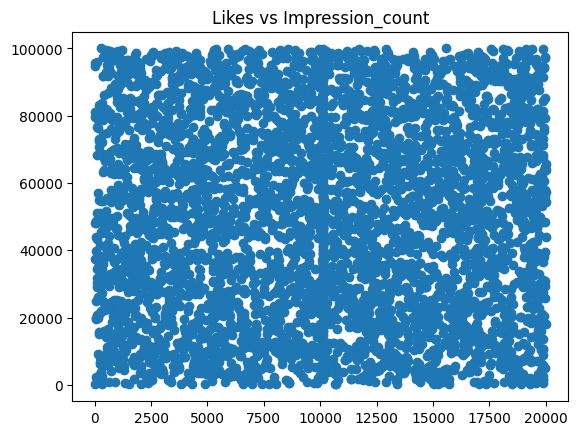

In [106]:
# Plot
plt.scatter(df['likes'], df['impression_count'])
plt.title("Likes vs Impression_count")
plt.show()

In [107]:
print(df.shape)
print(df.columns)
print(df.head())

(4562, 24)
Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate', 'year',
       'month', 'day', 'hashtag_count', 'engagement_score'],
      dtype='object')
   user_id   age  gender country  post_id post_type post_category    likes  \
0    25795  43.0  female  Brazil   496713     image       fitness   7011.0   
1    10860  33.0    male  Brazil   157326      reel          food  11750.0   
2    86820  32.0  female      UK   109864      text          food   4862.0   
3    64886  51.0   other  France   848877      text       fitness   5350.0   
4    16265  34.0   other      UK   449706     image       fitness  12682.0   

   comments  shares  ...  is_verified  device_type sentiment  \
0     354.0  1157.0  ...        False       mobile  negative   
1    2606.0  1807.0

In [111]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# change this if your column name different
date_col = 'date'

if date_col in df.columns:
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

    df['engagement_score'] = df['likes'] + df['comments'] + df['shares']

    df = df.dropna(subset=[date_col,'engagement_score'])

    daily = df.groupby(df[date_col].dt.date)['engagement_score'].mean()

    plt.figure()
    plt.plot(daily)
    plt.title("Daily Engagement Trend")
    plt.xticks(rotation=45)
    plt.show()

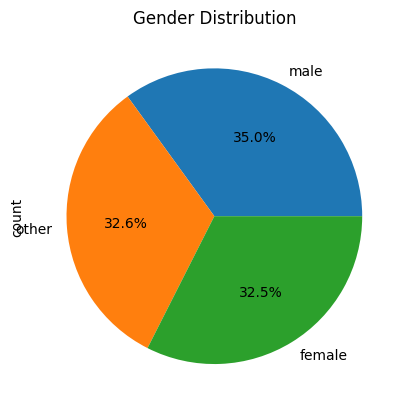

In [113]:
if 'gender' in df.columns:
    df['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
    plt.title("Gender Distribution")
    plt.show()

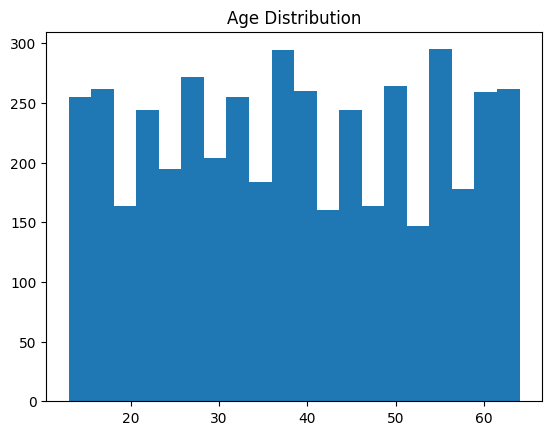

In [115]:
if 'age' in df.columns:
    plt.hist(df['age'], bins=20)
    plt.title("Age Distribution")
    plt.show()

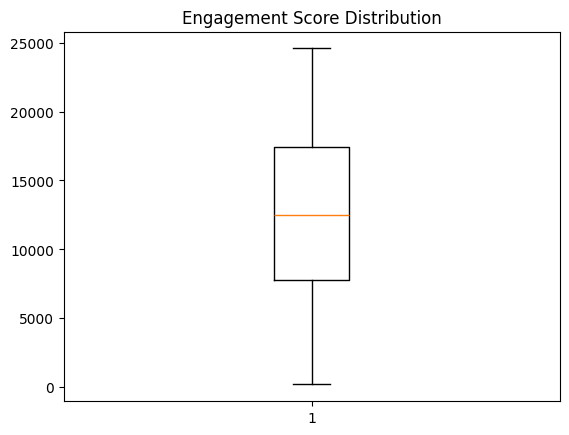

In [117]:
if 'engagement_score' in df.columns:
    plt.boxplot(df['engagement_score'])
    plt.title("Engagement Score Distribution")
    plt.show()

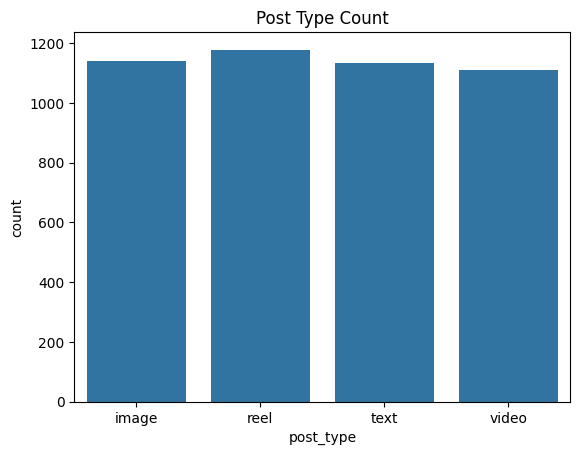

In [119]:
if 'post_type' in df.columns:
    sns.countplot(x='post_type', data=df)
    plt.title("Post Type Count")
    plt.show()

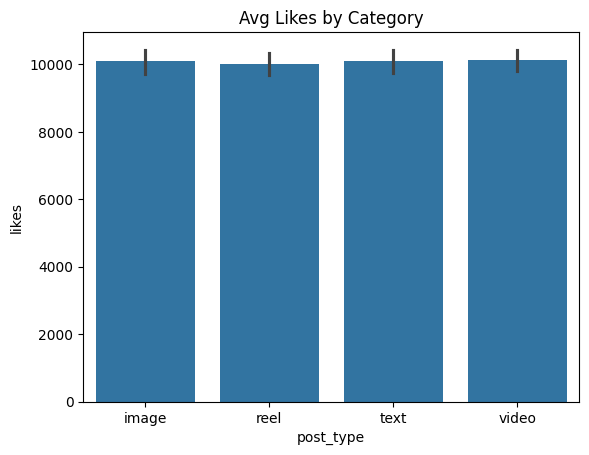

In [121]:
if 'post_type' in df.columns and 'likes' in df.columns:
    sns.barplot(x='post_type', y='likes', data=df)
    plt.title("Avg Likes by Category")
    plt.show()

In [123]:
if 'sentiment' in df.columns and 'followers' in df.columns:
    sns.violinplot(x='sentiment', y='followers', data=df)
    plt.title("Followers vs Sentiment")
    plt.show()

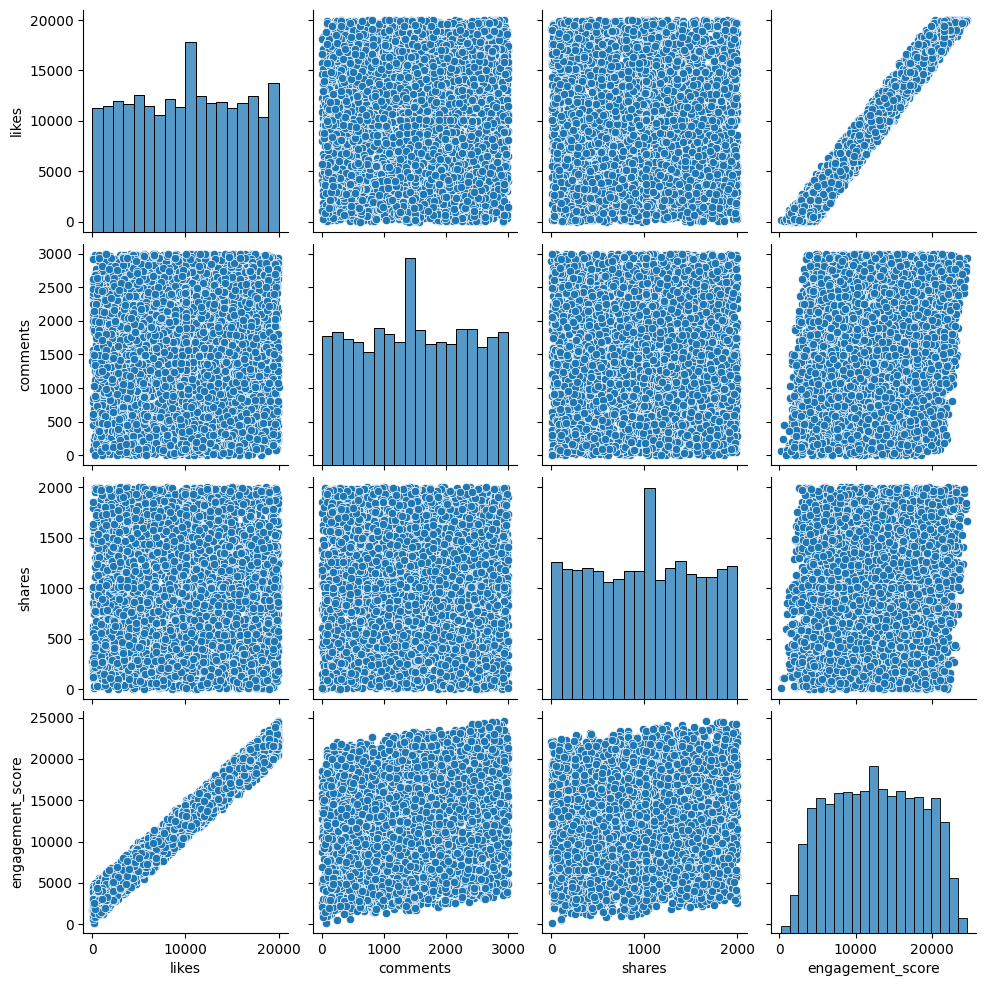

In [125]:
cols = ['likes','comments','shares','engagement_score']
cols = [col for col in cols if col in df.columns]

if len(cols) > 1:
    sns.pairplot(df[cols])
    plt.show()

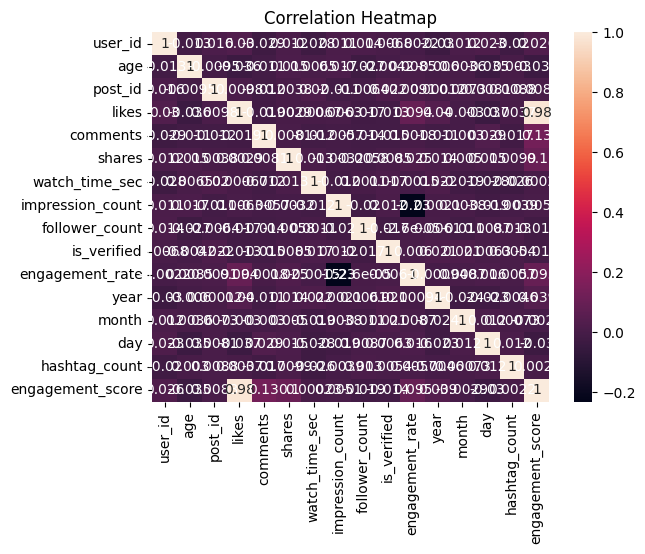

In [127]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [133]:
if 'device' in df.columns and 'engagement_score' in df.columns:
    sns.swarmplot(x='device', y='engagement_score', data=df)
    plt.title("Engagement vs Device")
    plt.show()

In [132]:
import plotly.express as px

if 'likes' in df.columns and 'impression_count' in df.columns:
    fig = px.scatter(df, x='likes', y='impression_count', color='post_type')
    fig.show()

In [135]:
df.groupby('post_type')['engagement_score'].mean()

,engagement_score
post_type,
image,12633.600000
reel,12493.936757
text,12606.029075
video,12607.125789
